# 第36篇｜常用检验方法：t检验 / 卡方检验 / 方差分析

> 这是「数据分析从入门到精通」系列的第 36 篇。p 值搞懂了，这篇来学具体的检验方法——t 检验、卡方检验、方差分析。遇到"两组数据有没有显著差异"这类问题，这三种方法基本能覆盖工作中 80% 的场景。

---

嗨，我是小荷～

上一篇学了假设检验的逻辑，今天来学三种最常用的具体检验方法：
- **t 检验**：比较均值
- **卡方检验**：分析分类数据的关联性
- **方差分析（ANOVA）**：同时比较 3 组以上的均值

先记住一个选择原则：


In [ ]:
比较两组均值          → t 检验
比较3+组均值          → 方差分析（ANOVA）
分析两个分类变量关联   → 卡方检验


---

## 一、t 检验

### 1.1 独立样本 t 检验（最常用）

比较两组**不同对象**的均值是否有差异：


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 场景：比较 A 组（旧策略）和 B 组（新策略）的平均客单价
group_a = np.random.normal(450, 80, 80)
group_b = np.random.normal(490, 90, 80)

t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)  # Welch's t-test（不假设方差相等）

print("独立样本 t 检验")
print(f"A 组均值：{group_a.mean():.1f}")
print(f"B 组均值：{group_b.mean():.1f}")
print(f"t 统计量：{t_stat:.4f}")
print(f"p 值：{p_val:.4f}")
print("结论：", "显著差异（p < 0.05）" if p_val < 0.05 else "无显著差异")


独立样本 t 检验
A 组均值：440.1
B 组均值：489.0
t 统计量：-3.8817
p 值：0.0002
结论： 显著差异（p < 0.05）


### 1.2 配对样本 t 检验

比较**同一组对象**前后两次测量的差异：


In [2]:
# 场景：同一批用户，活动前后的消费金额
np.random.seed(42)
n = 60
before = np.random.normal(400, 70, n)
after  = before + np.random.normal(25, 40, n)   # 活动后有提升

t_stat_p, p_val_p = stats.ttest_rel(before, after)
print("\n配对样本 t 检验（活动前后）")
print(f"活动前均值：{before.mean():.1f}")
print(f"活动后均值：{after.mean():.1f}")
print(f"平均提升：{(after - before).mean():.1f}")
print(f"p 值：{p_val_p:.4f}")
print("结论：", "活动效果显著" if p_val_p < 0.05 else "效果不显著")



配对样本 t 检验（活动前后）
活动前均值：389.2
活动后均值：414.0
平均提升：24.9
p 值：0.0000
结论： 活动效果显著


### 1.3 t 检验的前提条件

1. 数据近似正态分布（或样本量 n ≥ 30，CLT 保证）
2. 两组数据相互独立（独立样本 t 检验）
3. 如果方差差异很大，用 Welch's t 检验（`equal_var=False`）

---

## 二、卡方检验（χ² 检验）

卡方检验用于分析**两个分类变量之间是否有关联**。

### 2.1 独立性检验

卡方检验最常用的是独立性检验——看两个分类变量有没有关联：


In [3]:
# 场景：性别与购买意愿是否相关？
import pandas as pd

# 列联表（频数）
observed = np.array([
    [120, 80],   # 男：买 120，不买 80
    [90,  110],  # 女：买 90，不买 110
])

chi2, p_chi2, dof, expected = stats.chi2_contingency(observed)

print("卡方检验（性别 vs 购买意愿）")
print(f"χ² 统计量：{chi2:.4f}")
print(f"自由度：{dof}")
print(f"p 值：{p_chi2:.4f}")
print("期望频数矩阵：")
print(expected.round(1))
print("结论：", "性别与购买意愿显著相关" if p_chi2 < 0.05 else "无显著关联")


卡方检验（性别 vs 购买意愿）
χ² 统计量：8.4311
自由度：1
p 值：0.0037
期望频数矩阵：
[[105.  95.]
 [105.  95.]]
结论： 性别与购买意愿显著相关


### 2.2 从 DataFrame 直接做卡方检验

卡方检验用于分类变量的独立性检验：



列联表：
购买意愿    否   是
性别           
女      94  86
男     127  93

χ² = 1.0010, p = 0.3171


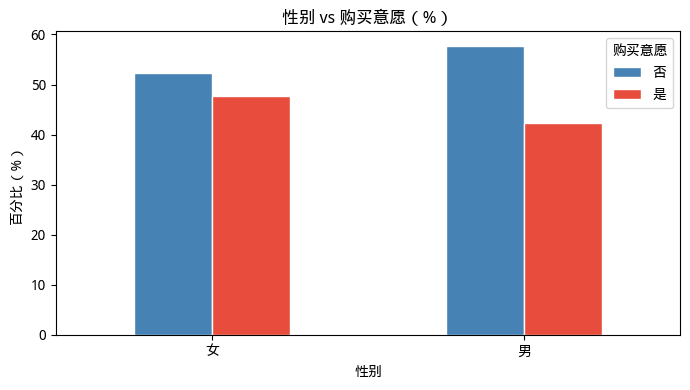

In [4]:
# 实际工作中更常见的方式
np.random.seed(42)
n = 400
df = pd.DataFrame({
    '性别':   np.random.choice(['男', '女'], n, p=[0.55, 0.45]),
    '购买意愿': np.random.choice(['是', '否'], n, p=[0.45, 0.55])
})

# 透视成列联表
ct = pd.crosstab(df['性别'], df['购买意愿'])
print("\n列联表：")
print(ct)

chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nχ² = {chi2:.4f}, p = {p:.4f}")

# 可视化
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', figsize=(7, 4), color=['steelblue', '#E74C3C'],
             rot=0, edgecolor='white')
plt.title('性别 vs 购买意愿（%）', fontweight='bold')
plt.ylabel('百分比（%）')
plt.legend(title='购买意愿')
plt.tight_layout()
plt.show()


---

## 三、方差分析（ANOVA）

当需要**同时比较 3 组或以上**时，不能多次做 t 检验（会导致第一类错误膨胀）。

ANOVA 的零假设：所有组的均值相等（μ₁ = μ₂ = μ₃ = ...）

### 3.1 单因素 ANOVA

ANOVA 比较两组以上的均值差异：


In [10]:
# 场景：比较 5 个城市的平均客单价是否有差异
np.random.seed(42)
beijing  = np.random.normal(500, 80, 60)
shanghai = np.random.normal(520, 90, 60)
guangzhou = np.random.normal(460, 75, 60)
shenzhen = np.random.normal(540, 85, 60)
hangzhou = np.random.normal(480, 70, 60)

f_stat, p_anova = stats.f_oneway(beijing, shanghai, guangzhou, shenzhen, hangzhou)

print("单因素 ANOVA（5个城市客单价比较）")
print(f"F 统计量：{f_stat:.4f}")
print(f"p 值：{p_anova:.4f}")
print("结论：", "各城市均值存在显著差异（p < 0.05）" if p_anova < 0.05 else "无显著差异")


单因素 ANOVA（5个城市客单价比较）
F 统计量：9.8556
p 值：0.0000
结论： 各城市均值存在显著差异（p < 0.05）


### 3.2 事后检验（Post-hoc）：找出哪两组有差异

ANOVA 只告诉你"至少有两组不同"，事后检验告诉你具体哪两组：


In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# 构造数据
data_all = np.concatenate([beijing, shanghai, guangzhou, shenzhen, hangzhou])
labels_all = ['北京']*60 + ['上海']*60 + ['广州']*60 + ['深圳']*60 + ['杭州']*60

tukey = pairwise_tukeyhsd(data_all, labels_all, alpha=0.05)
print("\nTukey HSD 事后检验结果：")
print(tukey)



Tukey HSD 事后检验结果：
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
    上海     北京 -32.0409 0.1743 -71.6116   7.5299  False
    上海     广州 -52.7749 0.0027 -92.3456 -13.2042   True
    上海     杭州 -40.9378 0.0385 -80.5085  -1.3671   True
    上海     深圳  25.1607 0.4079   -14.41  64.7314  False
    北京     广州 -20.7341 0.6035 -60.3048  18.8367  False
    北京     杭州   -8.897 0.9723 -48.4677  30.6738  False
    北京     深圳  57.2016 0.0009  17.6309  96.7723   True
    广州     杭州  11.8371  0.924 -27.7336  51.4078  False
    广州     深圳  77.9356    0.0  38.3649 117.5064   True
    杭州     深圳  66.0985 0.0001  26.5278 105.6693   True
------------------------------------------------------


---

## 四、非参数替代检验

当数据**严重偏离正态分布**时，用非参数检验（不依赖分布假设）：

| 参数检验 | 非参数替代 |
|---------|---------|
| 独立样本 t 检验 | Mann-Whitney U 检验 |
| 配对样本 t 检验 | Wilcoxon 符号秩检验 |
| 单因素 ANOVA | Kruskal-Wallis 检验 |


In [7]:
# Mann-Whitney U 检验（不要求正态性）
stat_mw, p_mw = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
print(f"\nMann-Whitney U 检验")
print(f"U 统计量：{stat_mw:.0f}，p 值：{p_mw:.4f}")



Mann-Whitney U 检验
U 统计量：2173，p 值：0.0005


---

## 五、📋 检验方法选择流程

检验方法这么多，什么时候用哪个？一张流程图搞定：


In [ ]:
数据类型？
├── 连续数值型
│     ├── 2组比较 → t 检验（正态/大样本）或 Mann-Whitney（偏态/小样本）
│     └── 3+组比较 → 单因素 ANOVA + Tukey 事后检验
│
└── 分类型
      └── 两个分类变量关联 → 卡方检验（期望频数≥5）


---

## 六、🔧 综合实战：会员等级是否影响客单价？

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


单因素 ANOVA：F = 215.73，p = 0.0000
→ 各等级客单价存在显著差异，进行事后检验...

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
    普通     金卡  179.2231   0.0  147.8389  210.6073   True
    普通     钻石  343.5035   0.0  305.7843  381.2226   True
    普通     银卡   60.5414   0.0   32.8631   88.2196   True
    金卡     钻石  164.2804   0.0  122.4348   206.126   True
    金卡     银卡 -118.6817   0.0 -151.7636  -85.5999   True
    钻石     银卡 -282.9621   0.0 -322.1051 -243.8191   True
--------------------------------------------------------


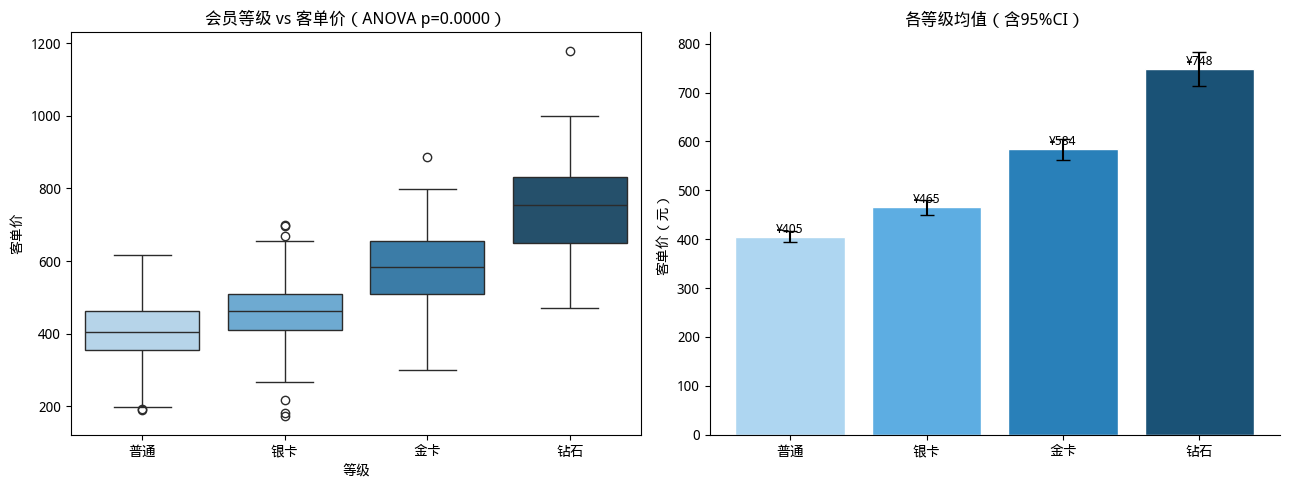

In [9]:
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2024)
levels = {'普通': (400, 80, 200), '银卡': (480, 90, 150), '金卡': (580, 100, 100), '钻石': (750, 120, 60)}

data_list, label_list = [], []
for lv, (mu, sigma, n) in levels.items():
    d = np.random.normal(mu, sigma, n)
    data_list.append(d)
    label_list.extend([lv] * n)

data_all = np.concatenate(data_list)

# ANOVA
f_stat, p_anova = stats.f_oneway(*data_list)
print(f"单因素 ANOVA：F = {f_stat:.2f}，p = {p_anova:.4f}")

if p_anova < 0.05:
    print("→ 各等级客单价存在显著差异，进行事后检验...\n")
    tukey = pairwise_tukeyhsd(data_all, label_list, alpha=0.05)
    print(tukey)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 箱线图
order = ['普通', '银卡', '金卡', '钻石']
df_plot = __import__('pandas').DataFrame({'等级': label_list, '客单价': data_all})
sns.boxplot(data=df_plot,hue='等级', x='等级', y='客单价', order=order,
             palette=['#AED6F1', '#5DADE2', '#2980B9', '#1A5276'], ax=axes[0])
axes[0].set_title(f'会员等级 vs 客单价（ANOVA p={p_anova:.4f}）', fontweight='bold')

# 均值+CI
means = [d.mean() for d in data_list]
sems  = [stats.sem(d) for d in data_list]
ci95  = [1.96 * s for s in sems]
axes[1].bar(order, means, color=['#AED6F1', '#5DADE2', '#2980B9', '#1A5276'], edgecolor='white')
axes[1].errorbar(order, means, yerr=ci95, fmt='none', color='black', capsize=5)
for i, (lv, m) in enumerate(zip(order, means)):
    axes[1].text(i, m + 8, f'¥{m:.0f}', ha='center', fontsize=9)
axes[1].set_title('各等级均值（含95%CI）', fontweight='bold')
axes[1].set_ylabel('客单价（元）')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---

## 七、📝 小结

| 检验方法 | 用途 | 前提 | 函数 |
|---------|------|------|------|
| 独立样本 t 检验 | 两组均值比较 | 正态/大样本 | `ttest_ind` |
| 配对样本 t 检验 | 同一组前后比较 | 正态/大样本 | `ttest_rel` |
| 卡方检验 | 两分类变量关联 | 期望频数≥5 | `chi2_contingency` |
| 单因素 ANOVA | 3+组均值比较 | 正态/方差齐性 | `f_oneway` |
| Mann-Whitney | t检验非参数替代 | 无 | `mannwhitneyu` |

---

## 八、🏋️ 课后练习

1. 你有一组数据，想比较"活动前"和"活动后"同一批用户的消费金额，应该用哪种 t 检验？做一次实验。
2. 用卡方检验验证：城市（北京/上海/广州）和购买品类（数码/服装/食品）是否独立。
3. 比较 3 种不同 UI 设计下的用户停留时长，应该用什么检验？跑一次 ANOVA + 事后检验。

练习1: 配对t检验 - 活动前后消费金额对比
【数据概览】
  样本量: 100 名用户

  活动前消费:
    均值: 190.72 元
    标准差: 73.42 元

  活动后消费:
    均值: 216.58 元
    标准差: 69.83 元

  变化量:
    均值: 25.87 元
    标准差: 45.80 元

【配对t检验】
  H0: μ_活动后 = μ_活动前 (无差异)
  H1: μ_活动后 ≠ μ_活动前 (有差异)

  t统计量 = 5.6478
  p值 = 0.000000

  结论 (α = 0.05):
    p值 < 0.05，拒绝原假设
    活动前后消费金额存在显著差异
    活动后消费平均增加 25.87 元


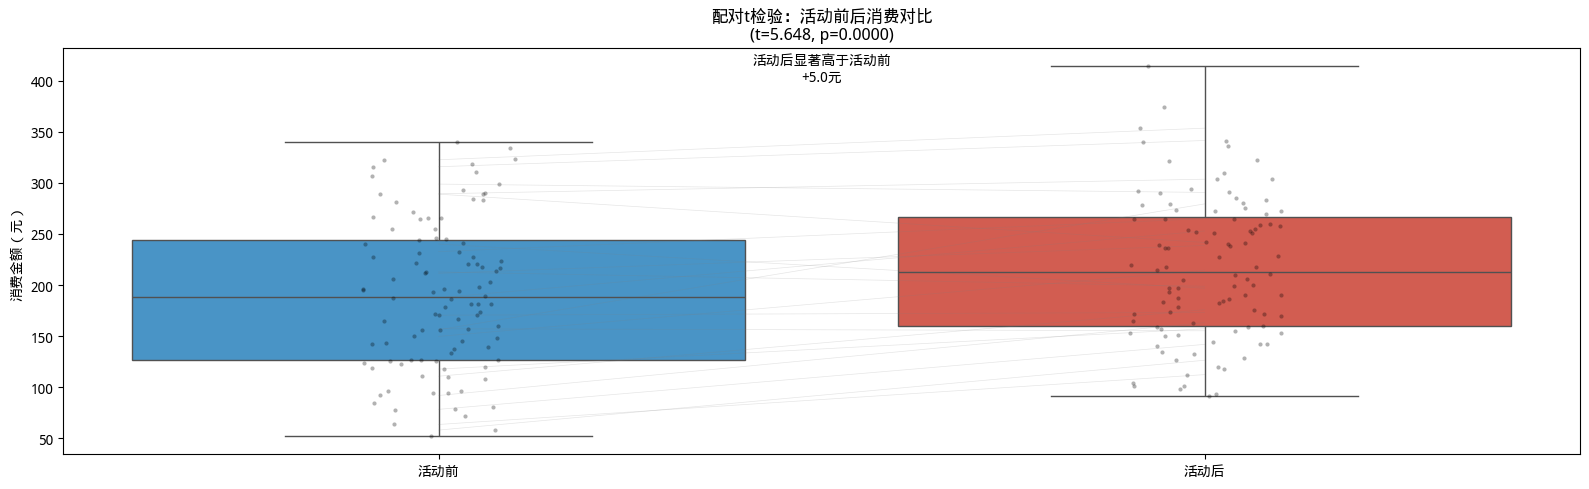

In [26]:
print("练习1: 配对t检验 - 活动前后消费金额对比")

# 模拟数据：同一批用户在活动前后的消费金额
n_customers = 100  # 100名用户

# 活动前消费金额（模拟）：均值200，标准差80
before_promotion = np.random.normal(200, 80, n_customers)

# 活动后消费金额（模拟）：均值提升到240，标准差相同
# 加上一定的正相关（之前消费高的活动后也倾向于高）
after_promotion = 20 + 0.8 * (before_promotion - 200) + np.random.normal(0, 40, n_customers) + 200

# 确保消费金额为正
before_promotion = np.maximum(before_promotion, 0)
after_promotion = np.maximum(after_promotion, 0)

# 创建DataFrame
df_paired = pd.DataFrame({
    '用户ID': range(1, n_customers + 1),
    '活动前': before_promotion,
    '活动后': after_promotion,
    '变化量': after_promotion - before_promotion
})

print(f"【数据概览】")
print(f"  样本量: {n_customers} 名用户")
print(f"\n  活动前消费:")
print(f"    均值: {df_paired['活动前'].mean():.2f} 元")
print(f"    标准差: {df_paired['活动前'].std():.2f} 元")
print(f"\n  活动后消费:")
print(f"    均值: {df_paired['活动后'].mean():.2f} 元")
print(f"    标准差: {df_paired['活动后'].std():.2f} 元")
print(f"\n  变化量:")
print(f"    均值: {df_paired['变化量'].mean():.2f} 元")
print(f"    标准差: {df_paired['变化量'].std():.2f} 元")

# 配对t检验
# H0: 活动前后消费金额无差异
# H1: 活动前后消费金额有差异
t_stat, p_value = stats.ttest_rel(after_promotion, before_promotion)

print(f"\n【配对t检验】")
print(f"  H0: μ_活动后 = μ_活动前 (无差异)")
print(f"  H1: μ_活动后 ≠ μ_活动前 (有差异)")
print(f"\n  t统计量 = {t_stat:.4f}")
print(f"  p值 = {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 < {alpha}，拒绝原假设")
    print(f"    活动前后消费金额存在显著差异")
    print(f"    活动后消费平均增加 {(after_promotion.mean() - before_promotion.mean()):.2f} 元")
else:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 >= {alpha}，不能拒绝原假设")
    print(f"    没有足够证据表明活动前后消费金额存在显著差异")


# 可视化
fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# 图1: 配对t检验 - 箱线图
df_melted = df_paired.melt(id_vars=['用户ID'], value_vars=['活动前', '活动后'], 
                            var_name='时间点', value_name='消费金额')
colors = {'活动前': '#3498db', '活动后': '#e74c3c'}
sns.boxplot(data=df_melted, x='时间点',hue='时间点', y='消费金额', ax=ax1, palette=colors)
sns.stripplot(data=df_melted, x='时间点', y='消费金额', ax=ax1, 
              color='black', alpha=0.3, size=3)

# 添加配对线
for i in range(min(20, n_customers)):  # 只画部分线避免太乱
    ax1.plot([0, 1], [before_promotion[i], after_promotion[i]], 
             'gray', alpha=0.2, linewidth=0.5)

ax1.set_title(f'配对t检验：活动前后消费对比\n(t={t_stat:.3f}, p={p_value:.4f})', fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('消费金额（元）')

# 添加显著性标注
if p_value < 0.05:
    max_val = max(df_melted['消费金额'].max(), 500)
    ax1.annotate(f'活动后显著高于活动前\n+{mean_diff:.1f}元', 
                xy=(0.5, max_val*0.8), fontsize=10, ha='center')

plt.tight_layout()
plt.show()

练习2: 卡方检验 - 城市与购买品类
【列联表 - 实际观测频数】
     数码   服装   食品
北京  120   80  100
上海   90  150   60
广州   60   70  170

  总计: 900

【行总和（各城市购买次数）】
  北京: 300
  上海: 300
  广州: 300

【列总和（各品类购买次数）】
  数码: 270
  服装: 300
  食品: 330

【期望频数（如果城市与品类独立）】
      数码     服装     食品
北京  90.0  100.0  110.0
上海  90.0  100.0  110.0
广州  90.0  100.0  110.0

【卡方检验】
  H0: 城市与购买品类独立（无关联）
  H1: 城市与购买品类不独立（有关联）

  卡方统计量 χ² = 114.3636
  自由度 df = (3-1) × (3-1) = 4
  p值 = 0.0000000000

  结论 (α = 0.05):
    p值 < 0.05，拒绝原假设
    城市与购买品类存在显著关联
    不同城市的消费偏好有显著差异


Text(715.0877525252527, 0.5, '城市')

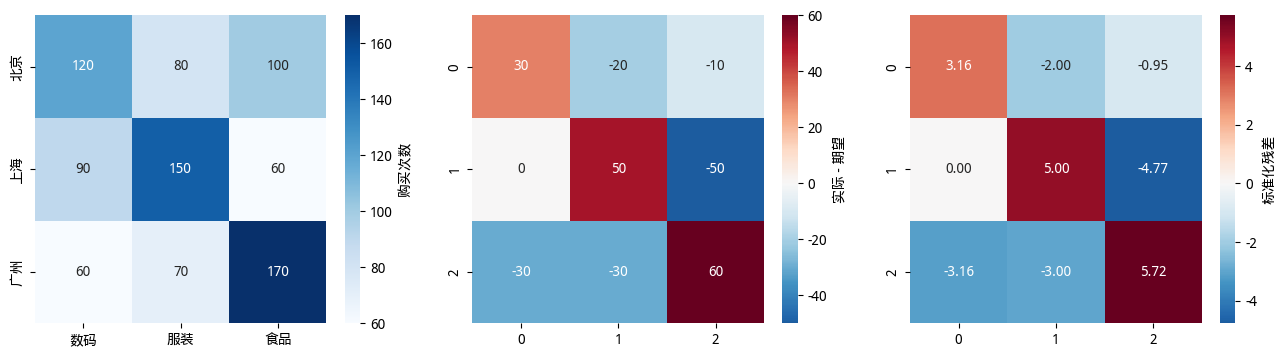

In [29]:
print("练习2: 卡方检验 - 城市与购买品类")

# 创建列联表数据
# 城市：北京/上海/广州
# 品类：数码/服装/食品
observed = np.array([
    [120, 80, 100],   # 北京: 数码120, 服装80, 食品100
    [90, 150, 60],    # 上海: 数码90, 服装150, 食品60
    [60, 70, 170]     # 广州: 数码60, 服装70, 食品170
])

# 创建DataFrame
cities = ['北京', '上海', '广州']
categories = ['数码', '服装', '食品']
df_contingency = pd.DataFrame(observed, index=cities, columns=categories)

print(f"【列联表 - 实际观测频数】")
print(df_contingency)
print(f"\n  总计: {observed.sum()}")

# 计算行总和与列总和
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
total = observed.sum()

print(f"\n【行总和（各城市购买次数）】")
for city, total_city in zip(cities, row_totals):
    print(f"  {city}: {total_city}")

print(f"\n【列总和（各品类购买次数）】")
for cat, total_cat in zip(categories, col_totals):
    print(f"  {cat}: {total_cat}")

# 计算期望频数
expected = np.outer(row_totals, col_totals) / total

print(f"\n【期望频数（如果城市与品类独立）】")
df_expected = pd.DataFrame(expected, index=cities, columns=categories)
print(df_expected.round(1))

# 卡方检验
chi2, p_value_chi2, dof, expected_freq = stats.chi2_contingency(observed)

print(f"\n【卡方检验】")
print(f"  H0: 城市与购买品类独立（无关联）")
print(f"  H1: 城市与购买品类不独立（有关联）")
print(f"\n  卡方统计量 χ² = {chi2:.4f}")
print(f"  自由度 df = ({len(cities)}-1) × ({len(categories)}-1) = {dof}")
print(f"  p值 = {p_value_chi2:.10f}")

alpha = 0.05
if p_value_chi2 < alpha:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 < {alpha}，拒绝原假设")
    print(f"    城市与购买品类存在显著关联")
    print(f"    不同城市的消费偏好有显著差异")
else:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 >= {alpha}，不能拒绝原假设")
    print(f"    没有足够证据表明城市与购买品类存在关联")

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# 图2: 卡方检验 - 热力图
ax21 = axes[0]
sns.heatmap(df_contingency, annot=True, fmt='d', cmap='Blues', ax=ax21,
            cbar_kws={'label': '购买次数'})
ax2.set_title(f'卡方检验：城市-品类列联表\n(χ²={chi2:.1f}, p={p_value_chi2:.4f})', fontsize=12)
ax2.set_xlabel('购买品类')
ax2.set_ylabel('城市')

# 实际vs期望热力图对比
ax22 = axes[1]
diff = observed - expected
sns.heatmap(diff, annot=True, fmt='.0f', cmap='RdBu_r', center=0, ax=ax22,
            cbar_kws={'label': '实际 - 期望'})
ax1.set_title('实际频数与期望频数之差\n(正值=超过期望, 负值=低于期望)', fontsize=12)
ax1.set_xlabel('购买品类')
ax1.set_ylabel('城市')

# 残差图
ax23 = axes[2]
# 标准化残差
std_resid = (observed - expected) / np.sqrt(expected)
sns.heatmap(std_resid, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax23,
            cbar_kws={'label': '标准化残差'})
ax2.set_title("标准化残差\n(绝对值>2表示显著偏离期望)", fontsize=12)
ax2.set_xlabel('购买品类')
ax2.set_ylabel('城市')

练习3: ANOVA + 事后检验 - 不同UI设计下的停留时长
【数据概览】
  三种UI设计，每组 80 名用户

各组描述统计:
        mean    std     min     max
UI设计                               
设计A   175.05  38.30   75.21  254.09
设计B   199.49  41.29  113.66  310.85
设计C   194.48  36.04  119.12  324.85

【单因素方差分析 (One-way ANOVA)】
  H0: μ_A = μ_B = μ_C (三组均值相等)
  H1: 至少有两组均值不相等

  F统计量 = 8.9487
  p值 = 0.000179

  结论 (α = 0.05):
    p值 < 0.05，拒绝原假设
    至少有两种UI设计的停留时长存在显著差异

  效应量 η² (eta-squared) = 0.0702
  效应大小: 中等效应

【事后检验: Tukey HSD】
  比较各组之间的差异:

  设计A vs 设计B:
    均值差: -24.44 秒
    p值: 0.000245
    差异: 显著

  设计A vs 设计C:
    均值差: -19.43 秒
    p值: 0.004679
    差异: 显著

  设计B vs 设计C:
    均值差: 5.01 秒
    p值: 0.690627
    差异: 不显著


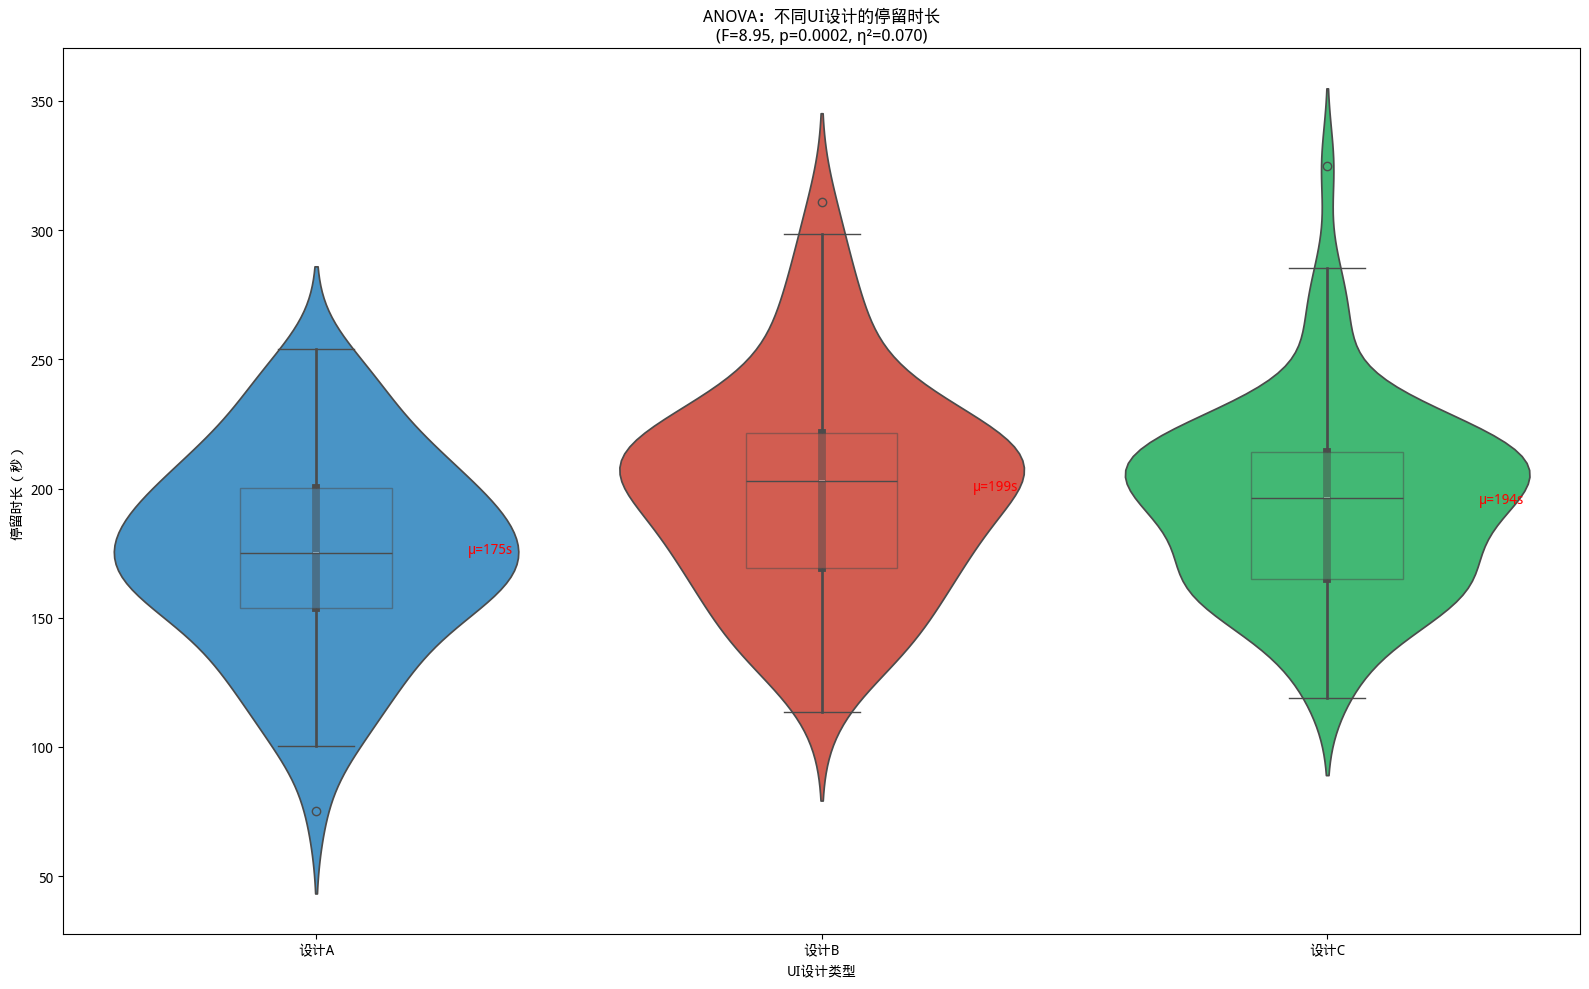

In [30]:
print("练习3: ANOVA + 事后检验 - 不同UI设计下的停留时长")

# 模拟数据：3种不同UI设计下的用户停留时长（秒）
np.random.seed(42)

# UI设计A：现代简约风，均值180秒
design_A = np.random.normal(180, 40, 80)

# UI设计B：信息丰富风，均值200秒
design_B = np.random.normal(200, 45, 80)

# UI设计C：经典商务风，均值190秒
design_C = np.random.normal(190, 35, 80)

# 创建DataFrame
df_anova = pd.DataFrame({
    '停留时长': np.concatenate([design_A, design_B, design_C]),
    'UI设计': ['设计A']*80 + ['设计B']*80 + ['设计C']*80
})

print(f"【数据概览】")
print(f"  三种UI设计，每组 {80} 名用户")
print(f"\n各组描述统计:")
print(df_anova.groupby('UI设计')['停留时长'].agg(['mean', 'std', 'min', 'max']).round(2))

# 单因素方差分析 (One-way ANOVA)
groups = [design_A, design_B, design_C]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"\n【单因素方差分析 (One-way ANOVA)】")
print(f"  H0: μ_A = μ_B = μ_C (三组均值相等)")
print(f"  H1: 至少有两组均值不相等")
print(f"\n  F统计量 = {f_stat:.4f}")
print(f"  p值 = {p_value_anova:.6f}")

alpha = 0.05
if p_value_anova < alpha:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 < {alpha}，拒绝原假设")
    print(f"    至少有两种UI设计的停留时长存在显著差异")
else:
    print(f"\n  结论 (α = {alpha}):")
    print(f"    p值 >= {alpha}，不能拒绝原假设")
    print(f"    没有足够证据表明不同UI设计的停留时长存在显著差异")

# 效应量 η² (eta-squared)
# η² = SS_between / SS_total
grand_mean = np.mean(np.concatenate(groups))
ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
ss_total = sum((np.concatenate(groups) - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\n  效应量 η² (eta-squared) = {eta_squared:.4f}")
if eta_squared < 0.01:
    effect = "微小"
elif eta_squared < 0.06:
    effect = "小"
elif eta_squared < 0.14:
    effect = "中等"
else:
    effect = "大"
print(f"  效应大小: {effect}效应")

# 事后检验：Tukey HSD
if p_value_anova < alpha:
    from scipy.stats import tukey_hsd
    
    result = tukey_hsd(design_A, design_B, design_C)
    
    print(f"\n【事后检验: Tukey HSD】")
    print(f"  比较各组之间的差异:")
    
    comparisons = [
        ('设计A', '设计B', design_A, design_B),
        ('设计A', '设计C', design_A, design_C),
        ('设计B', '设计C', design_B, design_C)
    ]
    
    pairs = [(0,1), (0,2), (1,2)]
    pair_names = [('设计A','设计B'), ('设计A','设计C'), ('设计B','设计C')]
    groups = [design_A, design_B, design_C]
    
    for (i,j), (name1,name2) in zip(pairs, pair_names):
        pval = float(result.pvalue[i][j])
        mean_diff = np.mean(groups[i]) - np.mean(groups[j])
        significance = "显著" if pval < alpha else "不显著"
        print(f"\n  {name1} vs {name2}:")
        print(f"    均值差: {mean_diff:.2f} 秒")
        print(f"    p值: {pval:.6f}")
        print(f"    差异: {significance}")

# 可视化
fig, ax3 = plt.subplots(1, 1, figsize=(16, 10))
df_grouped = pd.DataFrame({
    '停留时长': np.concatenate([design_A, design_B, design_C]),
    'UI设计': ['设计A']*80 + ['设计B']*80 + ['设计C']*80
})

colors = {'设计A': '#3498db', '设计B': '#e74c3c', '设计C': '#2ecc71'}
sns.violinplot(data=df_grouped, x='UI设计', hue='UI设计', y='停留时长', ax=ax3, palette=colors)
sns.boxplot(data=df_grouped, x='UI设计', hue='UI设计', y='停留时长', ax=ax3, 
            palette=colors, width=0.3, boxprops={'alpha': 0.5})

ax3.set_title(f'ANOVA：不同UI设计的停留时长\n(F={f_stat:.2f}, p={p_value_anova:.4f}, η²={eta_squared:.3f})', fontsize=12)
ax3.set_xlabel('UI设计类型')
ax3.set_ylabel('停留时长（秒）')

# 添加均值标注
means = [design_A.mean(), design_B.mean(), design_C.mean()]
for i, mean in enumerate(means):
    ax3.annotate(f'μ={mean:.0f}s', xy=(i, mean), xytext=(i+0.3, mean),
                fontsize=10, color='red')

plt.tight_layout()
plt.show()


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 37 篇：相关性分析 — 皮尔逊 / 斯皮尔曼 / 点二列**
>
> 下篇学相关性分析——学完之后你能定量回答「这两个变量到底有多相关」。

---

*跟着小荷，数据分析路上不迷路～*